<a href="https://colab.research.google.com/github/Evenjlin/deep-space-interference-ml/blob/main/notebooks/07_snr_estimation_and_grid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1 — self-contained bootstrap
from google.colab import userdata
import torch, os, sys

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_EMAIL = "evenjlinekka@gmail.com"
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/Evenjlin/deep-space-interference-ml.git"

if not os.path.exists('/content/deep-space-interference-ml'):
    !git clone {REPO_URL} /content/deep-space-interference-ml
%cd /content/deep-space-interference-ml
!git config --global user.email "{GITHUB_EMAIL}"
!git config --global user.name "Evenjlin"
!git remote set-url origin {REPO_URL}
!git pull

!pip install -r requirements.txt -q
sys.path.insert(0, os.getcwd())

Device: cuda
Cloning into '/content/deep-space-interference-ml'...
remote: Enumerating objects: 191, done.
remote: Counting objects: 100% (191/191), done.
remote: Compressing objects: 100% (153/153), done.
remote: Total 191 (delta 98), reused 103 (delta 34), pack-reused 0 (from 0)
Receiving objects: 100% (191/191), 8.14 MiB | 19.71 MiB/s, done.
Resolving deltas: 100% (98/98), done.
/content/deep-space-interference-ml
Already up to date.


In [2]:
# Cell 2 — train the SNR regression CNN
import numpy as np
import torch
from src.channel import SignalConfig, generate_soi, generate_noise
from src.model import SNRRegressionCNN, complex_to_channels

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg = SignalConfig(fd_max=0.0)
rng = np.random.default_rng(42)
N_SYMBOLS = 64

def make_snr_sample(cfg, n_symbols, snr_db, rng):
    s, bits, fd, phi_m = generate_soi(cfg, n_symbols, rng)
    w = generate_noise(len(s), rng)
    rho_snr = 10 ** (snr_db / 10)
    return s + w / np.sqrt(rho_snr)

SNR_RANGE = (-15, 30)  # matches the grid range visible in Fig.5-7's axes
M_TRAIN, M_VAL = 6000, 1500

def build_snr_dataset(n):
    X, y = [], []
    for _ in range(n):
        snr_db = rng.uniform(*SNR_RANGE)
        x = make_snr_sample(cfg, N_SYMBOLS, snr_db, rng)
        X.append(complex_to_channels(x))
        y.append(snr_db)
    return np.stack(X).astype(np.float32), np.array(y, dtype=np.float32)

X_train, y_train = build_snr_dataset(M_TRAIN)
X_val, y_val = build_snr_dataset(M_VAL)
print("X_train:", X_train.shape, " y range:", y_train.min(), y_train.max())

X_train: (6000, 2, 512)  y range: -14.998053 29.982891


In [3]:
# Cell 3 — DEBUG LADDER for the regression CNN (same discipline as Step 5)
model = SNRRegressionCNN(cfg.NSPS).to(device)
tiny_x = torch.tensor(X_train[:8], device=device)
out = model(tiny_x)
print("TEST 1: output shape", out.shape, "-- expect (8,)")
assert out.shape == (8,)

tiny_y = torch.tensor(y_train[:8], device=device)
loss_fn = torch.nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss = loss_fn(out, tiny_y)
loss.backward(); opt.step(); opt.zero_grad()
print(f"TEST 2: one grad step OK, loss={loss.item():.4f}")

small_x = torch.tensor(X_train[:300], device=device)
small_y = torch.tensor(y_train[:300], device=device)
losses = []
for _ in range(10):
    opt.zero_grad()
    out = model(small_x)
    loss = loss_fn(out, small_y)
    loss.backward(); opt.step()
    losses.append(loss.item())
print("TEST 3/4 losses:", [f"{l:.2f}" for l in losses])
assert losses[-1] < losses[0], "Loss did not decrease -- stop, don't proceed"
print("Debug ladder PASSED.")

TEST 1: output shape torch.Size([8]) -- expect (8,)
TEST 2: one grad step OK, loss=261.8162
TEST 3/4 losses: ['223.27', '220.51', '217.86', '215.35', '212.99', '210.80', '208.79', '206.92', '205.18', '203.55']
Debug ladder PASSED.


Epoch 1/30  train_loss=187.480  val_loss=170.489  val_mae=10.219 dB
Epoch 2/30  train_loss=143.806  val_loss=108.776  val_mae=7.738 dB
Epoch 3/30  train_loss=97.476  val_loss=61.484  val_mae=5.616 dB
Epoch 4/30  train_loss=60.929  val_loss=37.743  val_mae=4.677 dB
Epoch 5/30  train_loss=35.690  val_loss=26.377  val_mae=4.090 dB
Epoch 6/30  train_loss=19.819  val_loss=15.250  val_mae=3.133 dB
Epoch 7/30  train_loss=11.141  val_loss=10.900  val_mae=2.649 dB
Epoch 8/30  train_loss=7.236  val_loss=3.677  val_mae=1.560 dB
Epoch 9/30  train_loss=5.549  val_loss=3.247  val_mae=1.358 dB
Epoch 10/30  train_loss=3.860  val_loss=3.020  val_mae=1.334 dB
Epoch 11/30  train_loss=3.329  val_loss=2.085  val_mae=1.047 dB
Epoch 12/30  train_loss=2.994  val_loss=3.408  val_mae=1.388 dB
Epoch 13/30  train_loss=2.255  val_loss=1.345  val_mae=0.835 dB
Epoch 14/30  train_loss=2.689  val_loss=1.113  val_mae=0.815 dB
Epoch 15/30  train_loss=2.154  val_loss=1.143  val_mae=0.755 dB
Epoch 16/30  train_loss=2.502 

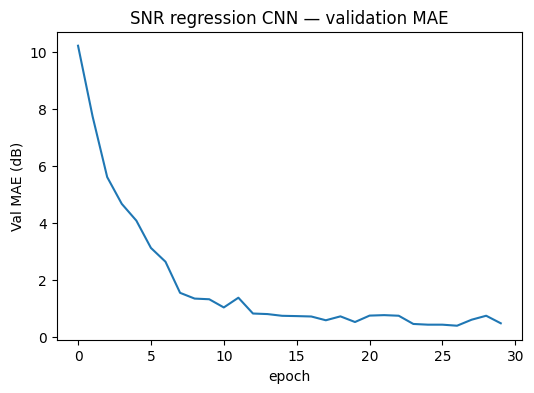

Final val MAE: 0.492 dB


In [4]:
# Cell 4 — full training
def train_snr_cnn(model, X_train, y_train, X_val, y_val, device,
                    epochs=30, batch_size=128, lr=1e-3, patience=5, seed=42):
    torch.manual_seed(seed)
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()
    Xt, yt = torch.tensor(X_train, device=device), torch.tensor(y_train, device=device)
    Xv, yv = torch.tensor(X_val, device=device), torch.tensor(y_val, device=device)

    history = {"train_loss": [], "val_loss": [], "val_mae": []}
    best_val, best_state, patience_ct = float("inf"), None, 0
    n = Xt.shape[0]

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        ep_losses = []
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            opt.zero_grad()
            out = model(Xt[idx])
            loss = loss_fn(out, yt[idx])
            loss.backward(); opt.step()
            ep_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_out = model(Xv)
            val_loss = loss_fn(val_out, yv).item()
            val_mae = torch.mean(torch.abs(val_out - yv)).item()

        train_loss = float(np.mean(ep_losses))
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_mae)
        print(f"Epoch {epoch+1}/{epochs}  train_loss={train_loss:.3f}  val_loss={val_loss:.3f}  val_mae={val_mae:.3f} dB")

        if val_loss < best_val:
            best_val, best_state, patience_ct = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            patience_ct += 1
            if patience_ct >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    model.load_state_dict(best_state)
    return model, history

model = SNRRegressionCNN(cfg.NSPS)
model, history = train_snr_cnn(model, X_train, y_train, X_val, y_val, device)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(history["val_mae"])
plt.xlabel("epoch"); plt.ylabel("Val MAE (dB)")
plt.title("SNR regression CNN — validation MAE")
plt.savefig("figures/snr_cnn_training.png", dpi=150)
plt.show()

import os
os.makedirs("checkpoints", exist_ok=True)
torch.save(model.state_dict(), "checkpoints/snr_cnn.pt")
print(f"Final val MAE: {history['val_mae'][-1]:.3f} dB")

In [5]:
# in Colab, after Ctrl+S on the notebook
!git add checkpoints/snr_cnn.pt figures/snr_cnn_training.png notebooks/07_snr_estimation_and_grid.ipynb src/model.py
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   checkpoints/snr_cnn.pt
	modified:   figures/snr_cnn_training.png



In [6]:
!git commit -m "Step 7: SNR regression CNN trained, val_mae=0.651dB"
!git push

[main 10cbb3d] Step 7: SNR regression CNN trained, val_mae=0.651dB
 2 files changed, 0 insertions(+), 0 deletions(-)
 rewrite checkpoints/snr_cnn.pt (91%)
 rewrite figures/snr_cnn_training.png (99%)
Enumerating objects: 11, done.
Counting objects: 100% (11/11), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 64.38 KiB | 10.73 MiB/s, done.
Total 6 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/Evenjlin/deep-space-interference-ml.git
   0953ff4..10cbb3d  main -> main


In [7]:
!git pull --no-edit

Already up to date.


In [8]:
!git commit -m "Step 7: add SNRRegressionCNN and corrected_covariance to src/model.py"
!git push

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date


In [9]:
!git push

Everything up-to-date


In [10]:
!git log --oneline -5

10cbb3d (HEAD -> main, origin/main, origin/HEAD) Step 7: SNR regression CNN trained, val_mae=0.651dB
0953ff4 step 7
21c7138 Merge branch 'main' of https://github.com/Evenjlin/deep-space-interference-ml
ba2c834 Step 7: SNR regression CNN trained, val_mae=0.651dB
b52844c Step 7: SNR regression CNN trained, val_mae=0.651dB


In [11]:
!git config pull.rebase false
!git pull --no-edit

Already up to date.


In [12]:
!git log --oneline --all --graph -10

* 10cbb3d (HEAD -> main, origin/main, origin/HEAD) Step 7: SNR regression CNN trained, val_mae=0.651dB
* 0953ff4 step 7
*   21c7138 Merge branch 'main' of https://github.com/Evenjlin/deep-space-interference-ml
|\  
| * b3c92b0 Step 7: SNR regression CNN trained, val_mae=0.651dB
* | ba2c834 Step 7: SNR regression CNN trained, val_mae=0.651dB
* | b52844c Step 7: SNR regression CNN trained, val_mae=0.651dB
|/  
* df9ee4b Step 7: SNR regression CNN + corrected covariance function (model + notebook, not yet run)
* 094dbac Consolidation: update README with project status summary
* 79da805 Step 6: compensated Mahalanobis run results (raw vs compensated AUC comparison)
* 730e633 Step 6: FFT frequency estimator + compensated Mahalanobis pipeline


In [13]:
!git push

Everything up-to-date


In [14]:
!git config --global pull.rebase false

In [15]:
!git log --oneline --all --graph -8

* 10cbb3d (HEAD -> main, origin/main, origin/HEAD) Step 7: SNR regression CNN trained, val_mae=0.651dB
* 0953ff4 step 7
*   21c7138 Merge branch 'main' of https://github.com/Evenjlin/deep-space-interference-ml
|\  
| * b3c92b0 Step 7: SNR regression CNN trained, val_mae=0.651dB
* | ba2c834 Step 7: SNR regression CNN trained, val_mae=0.651dB
* | b52844c Step 7: SNR regression CNN trained, val_mae=0.651dB
|/  
* df9ee4b Step 7: SNR regression CNN + corrected covariance function (model + notebook, not yet run)
* 094dbac Consolidation: update README with project status summary


In [16]:
# Cell 5 — reference covariance + both trained models, fully self-contained
import numpy as np
import torch
from src.channel import generate_soi, generate_noise, mix_signal, SignalConfig
from src.model import (estimate_covariance, mahalanobis_score, corrected_covariance,
                        SNRRegressionCNN, TimeShiftCNN, compensate_signal, complex_to_channels)
from sklearn.metrics import roc_auc_score

cfg_noshift = SignalConfig(fd_max=0.0)

# Load both trained models
timeshift_model = TimeShiftCNN(cfg.NSPS).to(device)
timeshift_model.load_state_dict(torch.load("checkpoints/timeshift_cnn.pt", map_location=device))
timeshift_model.eval()

snr_model = SNRRegressionCNN(cfg.NSPS).to(device)
snr_model.load_state_dict(torch.load("checkpoints/snr_cnn.pt", map_location=device))
snr_model.eval()
print("Both models loaded.")

def estimate_snr(x, model, device):
    channels = complex_to_channels(x).astype(np.float32)
    with torch.no_grad():
        inp = torch.tensor(channels, device=device).unsqueeze(0)
        return model(inp).item()

def make_clean_sample_local(cfg, n_symbols, snr_db, rng):
    s, bits, fd, phi_m = generate_soi(cfg, n_symbols, rng)
    w = generate_noise(len(s), rng)
    rho_snr = 10 ** (snr_db / 10)
    return s + w / np.sqrt(rho_snr)

REF_SNR_DB = 15.0
M_TRAIN_REF = 4000
clean_ref = [make_clean_sample_local(cfg_noshift, N_SYMBOLS, REF_SNR_DB, rng) for _ in range(M_TRAIN_REF)]
C_ref = estimate_covariance(clean_ref)
C_ref_inv = np.linalg.inv(C_ref)

M_REF = 4000
soi_only, noise_only = [], []
for _ in range(M_REF):
    s, bits, fd, phi_m = generate_soi(cfg_noshift, N_SYMBOLS, rng)
    soi_only.append(s)
    noise_only.append(generate_noise(len(s), rng))

C_SOI = estimate_covariance(soi_only)
C_noise = estimate_covariance(noise_only)
print("C_ref, C_SOI, C_noise ready:", C_ref.shape, C_SOI.shape, C_noise.shape)

Both models loaded.
C_ref, C_SOI, C_noise ready: (1024, 1024) (1024, 1024) (1024, 1024)


In [17]:
# Cell 6 — the grid sweep (kept modest: 5x5 = 25 points, 100 samples/point for speed)
from src.model import TimeShiftCNN

timeshift_model = TimeShiftCNN(cfg.NSPS).to(device)
timeshift_model.load_state_dict(torch.load("checkpoints/timeshift_cnn.pt", map_location=device))
timeshift_model.eval()
print("Time-shift CNN loaded.")

SIR_GRID = np.linspace(-10, 30, 5)
SNR_GRID = np.linspace(-15, 30, 5)
N_TEST_PER_POINT = 100
ITYPE = "chirp"  # BASE-PAPER FACT: Fig.5-7 specifically use chirp interference

grid_results = []

for snr_db in SNR_GRID:
    for sir_db in SIR_GRID:
        samples, labels = [], []
        for _ in range(N_TEST_PER_POINT):
            d = mix_signal(cfg, N_SYMBOLS, rng, interference_type=ITYPE,
                            contamination=0.5, sir_db_range=(sir_db, sir_db),
                            snr_db_range=(snr_db, snr_db), apply_shift=True)
            samples.append(d["x"]); labels.append(d["label"])
        labels = np.array(labels)

        # Raw (uncompensated)
        raw_scores = [mahalanobis_score(x, C_ref_inv) for x in samples]
        raw_auc = roc_auc_score(labels, raw_scores)

        # Compensated (shift correction only, fixed reference covariance)
        comp_scores = []
        snr_hats = []
        for x in samples:
            x_corr, fd_hat, k_hat = compensate_signal(x, cfg, timeshift_model, device)
            comp_scores.append(mahalanobis_score(x_corr, C_ref_inv))
            snr_hats.append(estimate_snr(x_corr, snr_model, device))
        comp_auc = roc_auc_score(labels, comp_scores)

        # Compensated + SNR-corrected covariance (Eq.17)
        snr_corr_scores = []
        for x, corr_score_x, snr_hat in zip(samples, comp_scores, snr_hats):
            x_corr, _, _ = compensate_signal(x, cfg, timeshift_model, device)
            C_corrected = corrected_covariance(C_SOI, C_noise, snr_hat)
            C_corrected_inv = np.linalg.inv(C_corrected + 1e-6*np.eye(C_corrected.shape[0]))
            snr_corr_scores.append(mahalanobis_score(x_corr, C_corrected_inv))
        snr_corr_auc = roc_auc_score(labels, snr_corr_scores)

        grid_results.append({
            "snr_db": snr_db, "sir_db": sir_db,
            "raw_auc": raw_auc, "compensated_auc": comp_auc, "snr_corrected_auc": snr_corr_auc
        })
        print(f"SNR={snr_db:6.1f} SIR={sir_db:6.1f}  raw={raw_auc:.3f} comp={comp_auc:.3f} snr_corr={snr_corr_auc:.3f}")

import pandas as pd
grid_df = pd.DataFrame(grid_results)
grid_df.to_csv("results/step7_grid_sweep.csv", index=False)

Time-shift CNN loaded.
SNR= -15.0 SIR= -10.0  raw=0.864 comp=0.725 snr_corr=0.998
SNR= -15.0 SIR=   0.0  raw=0.617 comp=0.552 snr_corr=0.631
SNR= -15.0 SIR=  10.0  raw=0.456 comp=0.533 snr_corr=0.482
SNR= -15.0 SIR=  20.0  raw=0.423 comp=0.360 snr_corr=0.402
SNR= -15.0 SIR=  30.0  raw=0.529 comp=0.589 snr_corr=0.536
SNR=  -3.8 SIR= -10.0  raw=0.994 comp=0.994 snr_corr=1.000
SNR=  -3.8 SIR=   0.0  raw=0.888 comp=0.850 snr_corr=0.985
SNR=  -3.8 SIR=  10.0  raw=0.550 comp=0.377 snr_corr=0.515
SNR=  -3.8 SIR=  20.0  raw=0.498 comp=0.477 snr_corr=0.497
SNR=  -3.8 SIR=  30.0  raw=0.425 comp=0.549 snr_corr=0.548
SNR=   7.5 SIR= -10.0  raw=0.999 comp=1.000 snr_corr=1.000
SNR=   7.5 SIR=   0.0  raw=0.957 comp=1.000 snr_corr=1.000
SNR=   7.5 SIR=  10.0  raw=0.686 comp=0.973 snr_corr=0.800
SNR=   7.5 SIR=  20.0  raw=0.439 comp=0.579 snr_corr=0.483
SNR=   7.5 SIR=  30.0  raw=0.478 comp=0.487 snr_corr=0.383
SNR=  18.8 SIR= -10.0  raw=1.000 comp=1.000 snr_corr=1.000
SNR=  18.8 SIR=   0.0  raw=0.943 

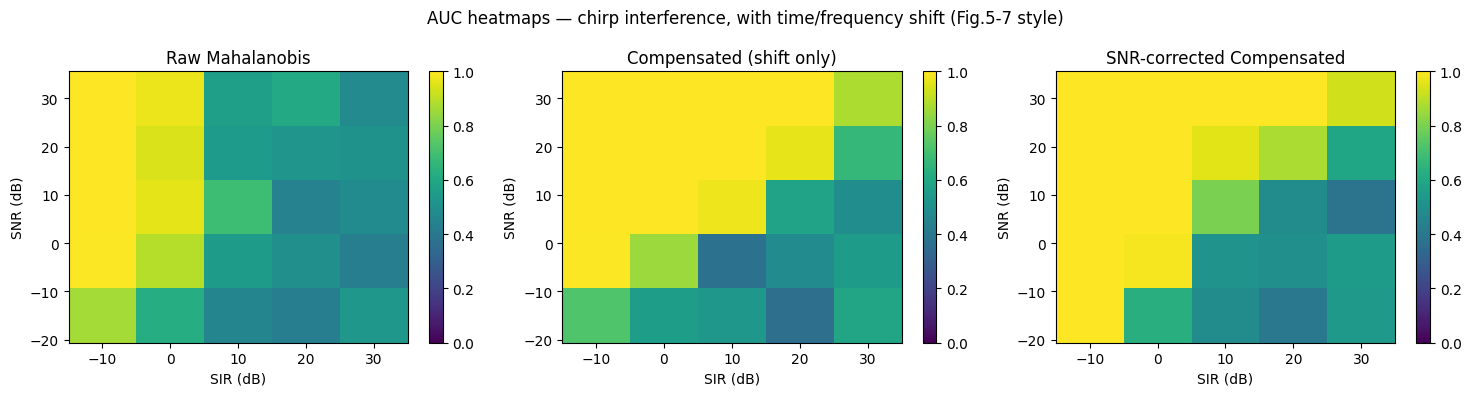

In [18]:
# Cell 7 — heatmap visualization matching paper's Fig.5-7 layout (SNR y-axis, SIR x-axis)
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ["Raw Mahalanobis", "Compensated (shift only)", "SNR-corrected Compensated"]
cols = ["raw_auc", "compensated_auc", "snr_corrected_auc"]

for ax, title, col in zip(axes, titles, cols):
    pivot = grid_df.pivot(index="snr_db", columns="sir_db", values=col)
    im = ax.pcolormesh(pivot.columns, pivot.index, pivot.values, vmin=0, vmax=1, cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("SIR (dB)")
    ax.set_ylabel("SNR (dB)")
    fig.colorbar(im, ax=ax)

plt.suptitle(f"AUC heatmaps — {ITYPE} interference, with time/frequency shift (Fig.5-7 style)")
plt.tight_layout()
plt.savefig("figures/step7_grid_heatmaps.png", dpi=150)
plt.show()

In [19]:
!git add results/step7_grid_sweep.csv figures/step7_grid_heatmaps.png notebooks/07_snr_estimation_and_grid.ipynb src/model.py
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   figures/step7_grid_heatmaps.png
	new file:   results/step7_grid_sweep.csv



In [20]:
!ls -la figures/step7_grid_heatmaps.png results/step7_grid_sweep.csv

-rw-r--r-- 1 root root 58070 Aug 29 14:05 figures/step7_grid_heatmaps.png
-rw-r--r-- 1 root root  1421 Aug 29 14:03 results/step7_grid_sweep.csv


In [21]:
!git config pull.rebase false
!git pull --no-edit

Already up to date.


In [22]:
!git add results/step7_grid_sweep.csv figures/step7_grid_heatmaps.png notebooks/07_snr_estimation_and_grid.ipynb src/model.py
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   figures/step7_grid_heatmaps.png
	new file:   results/step7_grid_sweep.csv



In [23]:
!git commit -m "Step 7: grid sweep (raw/compensated/SNR-corrected AUC across SIR/SNR) + heatmap visualization"
!git push


[main 1e8e252] Step 7: grid sweep (raw/compensated/SNR-corrected AUC across SIR/SNR) + heatmap visualization
 2 files changed, 26 insertions(+)
 create mode 100644 figures/step7_grid_heatmaps.png
 create mode 100644 results/step7_grid_sweep.csv
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 47.70 KiB | 15.90 MiB/s, done.
Total 6 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/Evenjlin/deep-space-interference-ml.git
   10cbb3d..1e8e252  main -> main


In [24]:
# Cell 8 — SNR CNN v2: trained WITH interference present (contamination-gated, all 4 types)
def build_snr_dataset_interference_aware(cfg, n_symbols, rng, n, snr_range, sir_range, contamination=0.5):
    types = ["tone", "square", "chirp", "fawgn"]
    X, y = [], []
    for _ in range(n):
        itype = types[rng.integers(0, len(types))]
        d = mix_signal(cfg, n_symbols, rng, interference_type=itype, contamination=contamination,
                        sir_db_range=sir_range, snr_db_range=snr_range, apply_shift=False)
        X.append(complex_to_channels(d["x"]))
        y.append(d["snr_db"])
    return np.stack(X).astype(np.float32), np.array(y, dtype=np.float32)

SIR_RANGE_TRAIN = (-10, 30)   # matches grid's SIR range
SNR_RANGE_TRAIN = (-15, 30)   # same as v1's training range, for a fair comparison

X_train_v2, y_train_v2 = build_snr_dataset_interference_aware(
    cfg_noshift, N_SYMBOLS, rng, 6000, SNR_RANGE_TRAIN, SIR_RANGE_TRAIN, contamination=0.5)
X_val_v2, y_val_v2 = build_snr_dataset_interference_aware(
    cfg_noshift, N_SYMBOLS, rng, 1500, SNR_RANGE_TRAIN, SIR_RANGE_TRAIN, contamination=0.5)

print("X_train_v2:", X_train_v2.shape)

# Debug ladder (same discipline as every trained model)
model_v2 = SNRRegressionCNN(cfg.NSPS).to(device)
tiny_x = torch.tensor(X_train_v2[:8], device=device)
out = model_v2(tiny_x)
assert out.shape == (8,)
tiny_y = torch.tensor(y_train_v2[:8], device=device)
loss_fn = torch.nn.MSELoss()
opt = torch.optim.Adam(model_v2.parameters(), lr=1e-3)
loss = loss_fn(out, tiny_y); loss.backward(); opt.step(); opt.zero_grad()
print(f"Debug: one grad step OK, loss={loss.item():.2f}")

# Full training
model_v2, history_v2 = train_snr_cnn(model_v2, X_train_v2, y_train_v2, X_val_v2, y_val_v2, device)
torch.save(model_v2.state_dict(), "checkpoints/snr_cnn_v2_interference_aware.pt")
print(f"v2 final val MAE (on interference-present validation set): {history_v2['val_mae'][-1]:.3f} dB")

X_train_v2: (6000, 2, 512)
Debug: one grad step OK, loss=264.27
Epoch 1/30  train_loss=195.594  val_loss=166.390  val_mae=10.313 dB
Epoch 2/30  train_loss=149.831  val_loss=103.475  val_mae=7.676 dB
Epoch 3/30  train_loss=102.348  val_loss=60.307  val_mae=5.369 dB
Epoch 4/30  train_loss=64.509  val_loss=48.430  val_mae=5.260 dB
Epoch 5/30  train_loss=40.039  val_loss=31.810  val_mae=4.141 dB
Epoch 6/30  train_loss=25.346  val_loss=23.276  val_mae=3.400 dB
Epoch 7/30  train_loss=18.406  val_loss=15.264  val_mae=2.488 dB
Epoch 8/30  train_loss=14.389  val_loss=11.543  val_mae=2.021 dB
Epoch 9/30  train_loss=12.839  val_loss=10.016  val_mae=2.011 dB
Epoch 10/30  train_loss=10.549  val_loss=9.401  val_mae=1.767 dB
Epoch 11/30  train_loss=9.609  val_loss=8.130  val_mae=1.749 dB
Epoch 12/30  train_loss=8.679  val_loss=8.073  val_mae=1.753 dB
Epoch 13/30  train_loss=8.321  val_loss=7.257  val_mae=1.739 dB
Epoch 14/30  train_loss=7.242  val_loss=7.540  val_mae=1.699 dB
Epoch 15/30  train_loss=

In [25]:
# Cell 9 — direct MAE comparison: v1 vs v2, on both clean-only and interference-present test data
def eval_mae(model, X, y, device):
    with torch.no_grad():
        preds = model(torch.tensor(X, device=device)).cpu().numpy()
    return np.mean(np.abs(preds - y))

X_clean_test, y_clean_test = build_snr_dataset_interference_aware(
    cfg_noshift, N_SYMBOLS, rng, 1000, SNR_RANGE_TRAIN, SIR_RANGE_TRAIN, contamination=0.0)  # force no interference
X_interf_test, y_interf_test = build_snr_dataset_interference_aware(
    cfg_noshift, N_SYMBOLS, rng, 1000, SNR_RANGE_TRAIN, SIR_RANGE_TRAIN, contamination=1.0)  # force interference present

print("MAE on CLEAN-only test data:")
print(f"  v1 (original): {eval_mae(snr_model, X_clean_test, y_clean_test, device):.3f} dB")
print(f"  v2 (retrained): {eval_mae(model_v2, X_clean_test, y_clean_test, device):.3f} dB")
print("MAE on INTERFERENCE-PRESENT test data:")
print(f"  v1 (original): {eval_mae(snr_model, X_interf_test, y_interf_test, device):.3f} dB")
print(f"  v2 (retrained): {eval_mae(model_v2, X_interf_test, y_interf_test, device):.3f} dB")

MAE on CLEAN-only test data:
  v1 (original): 0.405 dB
  v2 (retrained): 0.926 dB
MAE on INTERFERENCE-PRESENT test data:
  v1 (original): 4.953 dB
  v2 (retrained): 1.668 dB


In [26]:
# Cell 10 — paired grid comparison: same samples, v1 vs v2 SNR-corrected AUC
grid_results_v2 = []

for snr_db in SNR_GRID:
    for sir_db in SIR_GRID:
        samples, labels = [], []
        for _ in range(N_TEST_PER_POINT):
            d = mix_signal(cfg, N_SYMBOLS, rng, interference_type=ITYPE,
                            contamination=0.5, sir_db_range=(sir_db, sir_db),
                            snr_db_range=(snr_db, snr_db), apply_shift=True)
            samples.append(d["x"]); labels.append(d["label"])
        labels = np.array(labels)

        comp_scores, snr_hats_v1, snr_hats_v2, x_corrs = [], [], [], []
        for x in samples:
            x_corr, fd_hat, k_hat = compensate_signal(x, cfg, timeshift_model, device)
            x_corrs.append(x_corr)
            comp_scores.append(mahalanobis_score(x_corr, C_ref_inv))
            snr_hats_v1.append(estimate_snr(x_corr, snr_model, device))
            snr_hats_v2.append(estimate_snr(x_corr, model_v2, device))
        comp_auc = roc_auc_score(labels, comp_scores)

        def score_with_snr_model(snr_hats):
            scores = []
            for x_corr, snr_hat in zip(x_corrs, snr_hats):
                C_corrected = corrected_covariance(C_SOI, C_noise, snr_hat)
                C_corrected_inv = np.linalg.inv(C_corrected + 1e-6*np.eye(C_corrected.shape[0]))
                scores.append(mahalanobis_score(x_corr, C_corrected_inv))
            return roc_auc_score(labels, scores)

        auc_v1 = score_with_snr_model(snr_hats_v1)
        auc_v2 = score_with_snr_model(snr_hats_v2)

        grid_results_v2.append({"snr_db": snr_db, "sir_db": sir_db, "compensated_auc": comp_auc,
                                  "snr_corrected_v1_auc": auc_v1, "snr_corrected_v2_auc": auc_v2})
        print(f"SNR={snr_db:6.1f} SIR={sir_db:6.1f}  comp={comp_auc:.3f}  v1={auc_v1:.3f}  v2={auc_v2:.3f}")

grid_df_v2 = pd.DataFrame(grid_results_v2)
grid_df_v2.to_csv("results/step7b_snr_v1_vs_v2_comparison.csv", index=False)

SNR= -15.0 SIR= -10.0  comp=0.744  v1=0.999  v2=0.999
SNR= -15.0 SIR=   0.0  comp=0.516  v1=0.593  v2=0.589
SNR= -15.0 SIR=  10.0  comp=0.553  v1=0.472  v2=0.468
SNR= -15.0 SIR=  20.0  comp=0.513  v1=0.462  v2=0.464
SNR= -15.0 SIR=  30.0  comp=0.528  v1=0.521  v2=0.525
SNR=  -3.8 SIR= -10.0  comp=0.993  v1=1.000  v2=1.000
SNR=  -3.8 SIR=   0.0  comp=0.924  v1=0.997  v2=0.977
SNR=  -3.8 SIR=  10.0  comp=0.632  v1=0.674  v2=0.696
SNR=  -3.8 SIR=  20.0  comp=0.465  v1=0.535  v2=0.502
SNR=  -3.8 SIR=  30.0  comp=0.483  v1=0.553  v2=0.559
SNR=   7.5 SIR= -10.0  comp=1.000  v1=1.000  v2=1.000
SNR=   7.5 SIR=   0.0  comp=1.000  v1=0.999  v2=0.988
SNR=   7.5 SIR=  10.0  comp=0.966  v1=0.756  v2=0.884
SNR=   7.5 SIR=  20.0  comp=0.676  v1=0.601  v2=0.575
SNR=   7.5 SIR=  30.0  comp=0.530  v1=0.461  v2=0.532
SNR=  18.8 SIR= -10.0  comp=1.000  v1=1.000  v2=1.000
SNR=  18.8 SIR=   0.0  comp=1.000  v1=1.000  v2=1.000
SNR=  18.8 SIR=  10.0  comp=1.000  v1=0.988  v2=1.000
SNR=  18.8 SIR=  20.0  comp=

In [27]:
!ls -la checkpoints/snr_cnn_v2_interference_aware.pt results/step7b_snr_v1_vs_v2_comparison.csv

-rw-r--r-- 1 root root 42716 Aug 29 14:08 checkpoints/snr_cnn_v2_interference_aware.pt
-rw-r--r-- 1 root root  1410 Aug 29 14:21 results/step7b_snr_v1_vs_v2_comparison.csv


In [28]:
!git config pull.rebase false
!git pull --no-edit

Already up to date.


In [29]:
!git add checkpoints/snr_cnn_v2_interference_aware.pt results/step7b_snr_v1_vs_v2_comparison.csv notebooks/07_snr_estimation_and_grid.ipynb
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   checkpoints/snr_cnn_v2_interference_aware.pt
	new file:   results/step7b_snr_v1_vs_v2_comparison.csv



In [30]:
!git commit -m "Step 7b: interference-aware SNR estimator (v2) + paired v1/v2 grid comparison"
!git push

[main e252c3a] Step 7b: interference-aware SNR estimator (v2) + paired v1/v2 grid comparison
 2 files changed, 26 insertions(+)
 create mode 100644 checkpoints/snr_cnn_v2_interference_aware.pt
 create mode 100644 results/step7b_snr_v1_vs_v2_comparison.csv
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 34.64 KiB | 11.54 MiB/s, done.
Total 6 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/Evenjlin/deep-space-interference-ml.git
   1e8e252..e252c3a  main -> main
